In [3]:
# STEP 1 : Load the Dataset

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/xy_data.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

First 5 rows of the dataset:
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340

Dataset Shape:
(1500, 2)

Columns:
['x', 'y']


In [4]:
# STEP 2 : Dataset Inspection & Data Quality Check

print("=" * 60)
print("Dataset Information")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Duplicate Rows")
print("=" * 60)
print(df.duplicated().sum())

print("\n" + "=" * 60)
print("Summary Statistics")
print("=" * 60)
print(df.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1500 non-null   float64
 1   y       1500 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB
None

Data Types
x    float64
y    float64
dtype: object

Missing Values
x    0
y    0
dtype: int64

Duplicate Rows
0

Summary Statistics
                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


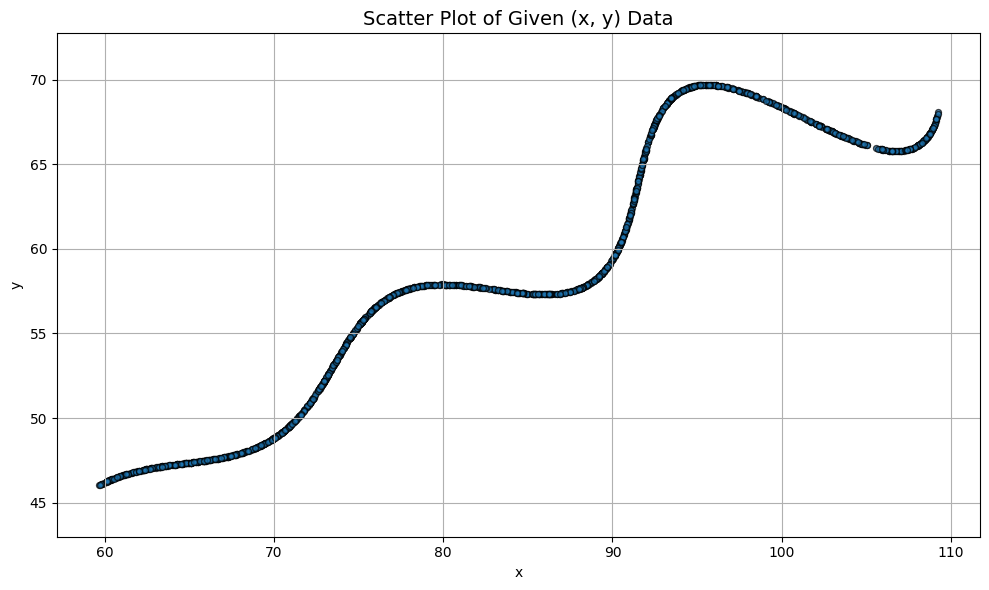

In [5]:
# STEP 3 : Exploratory Data Analysis (EDA) & Curve Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["x"],
    df["y"],
    s=18,
    alpha=0.7,
    edgecolor="black"
)

plt.title("Scatter Plot of Given (x, y) Data", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.axis("equal")
plt.tight_layout()

plt.show()

In [6]:
# STEP 4 : Define the Mathematical Model

import numpy as np

def parametric_curve(t, theta, M, X):
    """
    Generates (x, y) coordinates from the given parametric equation.

    """

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return x, y


print("Parametric curve function created successfully.")

Parametric curve function created successfully.


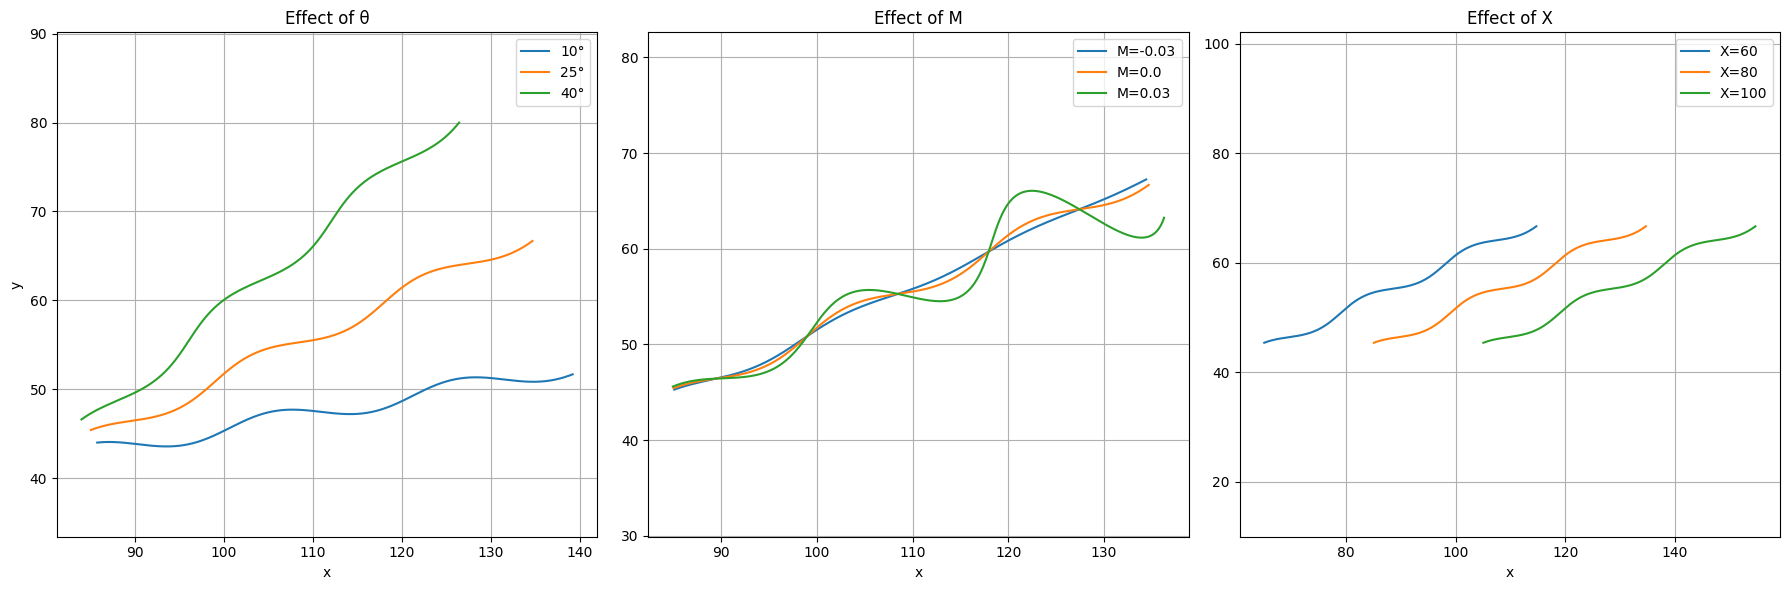

In [7]:
# STEP 5 : Parameter Sensitivity Analysis

import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(6, 60, 600)

# Approximate values (ONLY for visualization)
theta_base = np.deg2rad(25)   # 25 degrees
M_base = 0.0
X_base = 80

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Effect of Theta
theta_values = [10, 25, 40]

for theta_deg in theta_values:
    theta = np.deg2rad(theta_deg)
    x, y = parametric_curve(t, theta, M_base, X_base)

    axes[0].plot(x, y, label=f"{theta_deg}°")

axes[0].set_title("Effect of θ")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].axis("equal")
axes[0].grid(True)
axes[0].legend()

# Effect of M
M_values = [-0.03, 0.0, 0.03]

for M in M_values:
    x, y = parametric_curve(t, theta_base, M, X_base)

    axes[1].plot(x, y, label=f"M={M}")

axes[1].set_title("Effect of M")
axes[1].set_xlabel("x")
axes[1].axis("equal")
axes[1].grid(True)
axes[1].legend()

# Effect of X
X_values = [60, 80, 100]

for X in X_values:
    x, y = parametric_curve(t, theta_base, M_base, X)

    axes[2].plot(x, y, label=f"X={X}")

axes[2].set_title("Effect of X")
axes[2].set_xlabel("x")
axes[2].axis("equal")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
# STEP 6 : Define Initial Guess and Parameter Bounds

import numpy as np

# Initial parameter guess
theta_initial = np.deg2rad(25)   # 25 degrees converted to radians
M_initial = 0.0
X_initial = 50.0

initial_guess = [theta_initial, M_initial, X_initial]

# Parameter bounds from the assignment
lower_bounds = [
    np.deg2rad(0.1),   # Theta > 0°
    -0.05,             # Minimum M
    0                  # Minimum X
]

upper_bounds = [
    np.deg2rad(49.9),  # Theta < 50°
    0.05,              # Maximum M
    100                # Maximum X
]

print("=" * 60)
print("Initial Guess")
print("=" * 60)

print(f"Theta : {np.degrees(theta_initial):.2f} degrees")
print(f"M     : {M_initial:.4f}")
print(f"X     : {X_initial:.2f}")

print("\nParameter Bounds")

print(f"Theta : 0°  < θ < 50°")
print(f"M     : -0.05 < M < 0.05")
print(f"X     : 0 < X < 100")

Initial Guess
Theta : 25.00 degrees
M     : 0.0000
X     : 50.00

Parameter Bounds
Theta : 0°  < θ < 50°
M     : -0.05 < M < 0.05
X     : 0 < X < 100


In [9]:
# DATASET DIAGNOSTIC CHECK

import numpy as np

print("="*70)
print("DATASET DIAGNOSTIC REPORT")
print("="*70)

# Basic Information
print("\n1. Dataset Shape")
print(df.shape)

print("\n2. First 10 Rows")
print(df.head(10))

print("\n3. Last 10 Rows")
print(df.tail(10))

# Difference between consecutive points
dx = np.diff(df["x"])
dy = np.diff(df["y"])

dist = np.sqrt(dx**2 + dy**2)

print("\n4. Consecutive Point Distance Statistics")
print("----------------------------------------")
print(f"Minimum Distance : {dist.min():.6f}")
print(f"Maximum Distance : {dist.max():.6f}")
print(f"Mean Distance    : {dist.mean():.6f}")
print(f"Std Distance     : {dist.std():.6f}")

# Check if x is monotonic
print("\n5. Is x Monotonic?")
print("------------------")
print("Increasing :", np.all(dx >= 0))
print("Decreasing :", np.all(dx <= 0))

# Check if y is monotonic
print("\n6. Is y Monotonic?")
print("------------------")
print("Increasing :", np.all(dy >= 0))
print("Decreasing :", np.all(dy <= 0))

# Sign changes
print("\n7. Direction Changes")
print("--------------------")

x_sign_changes = np.sum(np.diff(np.sign(dx)) != 0)
y_sign_changes = np.sum(np.diff(np.sign(dy)) != 0)

print("X sign changes :", x_sign_changes)
print("Y sign changes :", y_sign_changes)

# Average movement
print("\n8. Average Step")
print("--------------------")
print("Average dx :", np.mean(dx))
print("Average dy :", np.mean(dy))

# Correlation
print("\n9. Correlation")
print("--------------------")
print(df.corr())

# Distance between first and last point
first = df.iloc[0]
last = df.iloc[-1]

endpoint_distance = np.sqrt(
    (last["x"]-first["x"])**2 +
    (last["y"]-first["y"])**2
)

print("\n10. End Point Distance")
print("----------------------")
print(endpoint_distance)


DATASET DIAGNOSTIC REPORT

1. Dataset Shape
(1500, 2)

2. First 10 Rows
            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
5   69.284134  48.406086
6   77.810130  57.588833
7   91.296880  63.031350
8  107.668410  65.914050
9   76.406890  56.871525

3. Last 10 Rows
              x          y
1490  72.969310  52.189995
1491  62.359524  46.953130
1492  61.240780  46.667980
1493  74.017296  53.971700
1494  84.350880  57.414730
1495  99.653260  68.500260
1496  66.533380  47.578316
1497  83.447020  57.533510
1498  63.372417  47.135735
1499  66.023470  47.496170

4. Consecutive Point Distance Statistics
----------------------------------------
Minimum Distance : 0.021361
Maximum Distance : 52.688993
Mean Distance    : 18.624593
Std Distance     : 12.526414

5. Is x Monotonic?
------------------
Increasing : False
Decreasing : False

6. Is y Monotonic?
------------------
Increasing : False
Decrea

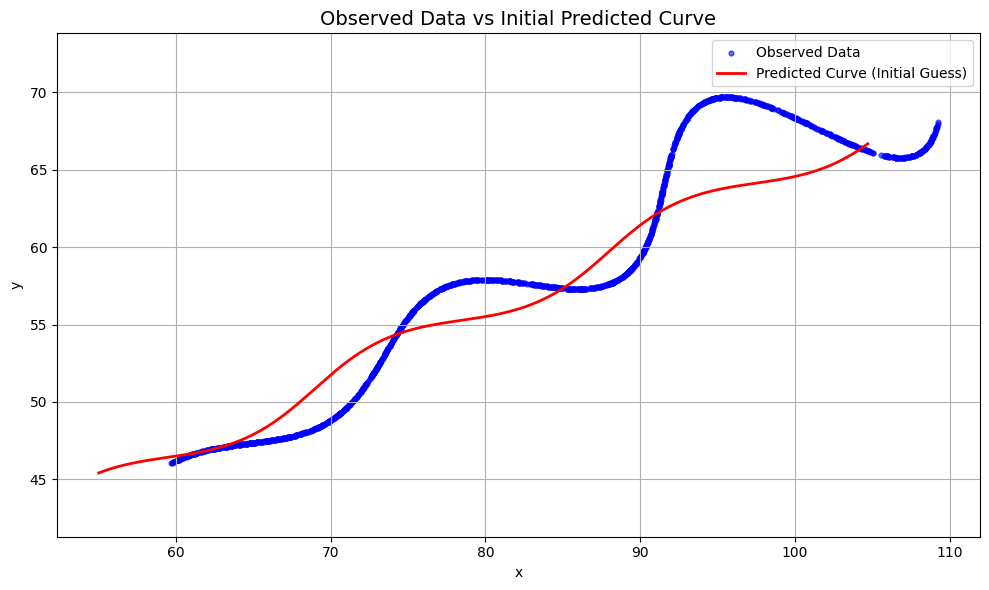

In [10]:
# STEP 7 : Generate a Dense Predicted Curve

t_dense = np.linspace(6, 60, 5000)

# initial values from step 6
theta = theta_initial
M = M_initial
X = X_initial

# Generate the predicted curve
x_pred, y_pred = parametric_curve(t_dense, theta, M, X)

plt.figure(figsize=(10, 6))

plt.scatter(
    df["x"],
    df["y"],
    s=12,
    color="blue",
    alpha=0.6,
    label="Observed Data"
)

plt.plot(
    x_pred,
    y_pred,
    color="red",
    linewidth=2,
    label="Predicted Curve (Initial Guess)"
)

plt.title("Observed Data vs Initial Predicted Curve", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# STEP 8 : Build the Objective (Loss) Function
from scipy.spatial import cKDTree

def objective_function(params):
    """
    Computes the total L1 distance between the observed points
    and the predicted parametric curve.

    """

    theta, M, X = params

    # Generate predicted curve
    x_pred, y_pred = parametric_curve(
        t_dense,
        theta,
        M,
        X
    )

    predicted_points = np.column_stack((x_pred, y_pred))

    # Build KD-Tree
    tree = cKDTree(predicted_points)

    observed_points = df[["x", "y"]].values

    # Find nearest predicted point for every observed point
    distances, _ = tree.query(observed_points)

    # L1 distance
    total_error = np.sum(np.abs(distances))

    return total_error


# Evaluating the initial guess
initial_error = objective_function(initial_guess)

print("=" * 60)
print("Initial Objective Function Value")
print("=" * 60)
print(f"L1 Error : {initial_error:.6f}")

Initial Objective Function Value
L1 Error : 3003.010206


In [12]:
# STEP 9 : Optimize the Unknown Parameters

from scipy.optimize import minimize

bounds = [
    (np.deg2rad(0.1), np.deg2rad(49.9)),
    (-0.05, 0.05),
    (0, 100)
]

result = minimize(
    objective_function,
    x0=initial_guess,
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 500,
        "disp": True
    }
)

theta_opt, M_opt, X_opt = result.x

print("=" * 60)
print("Optimization Results")
print("=" * 60)

print(f"Optimization Successful : {result.success}")
print(f"Message                 : {result.message}")

print()

print(f"Theta (degrees) : {np.degrees(theta_opt):.6f}")
print(f"Theta (radians) : {theta_opt:.8f}")

print(f"M               : {M_opt:.8f}")

print(f"X               : {X_opt:.8f}")

print()

print(f"Final L1 Error  : {result.fun:.6f}")

/tmp/ipykernel_4373/3331819506.py:11: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Optimization Results
Optimization Successful : True
Message                 : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Theta (degrees) : 29.999947
Theta (radians) : 0.52359786
M               : 0.02999992
X               : 54.99994582

Final L1 Error  : 4.849061


FINAL MODEL EVALUATION
L1 Error      : 4.849061
Mean Error    : 0.003233
Maximum Error : 0.009295
RMSE          : 0.003785


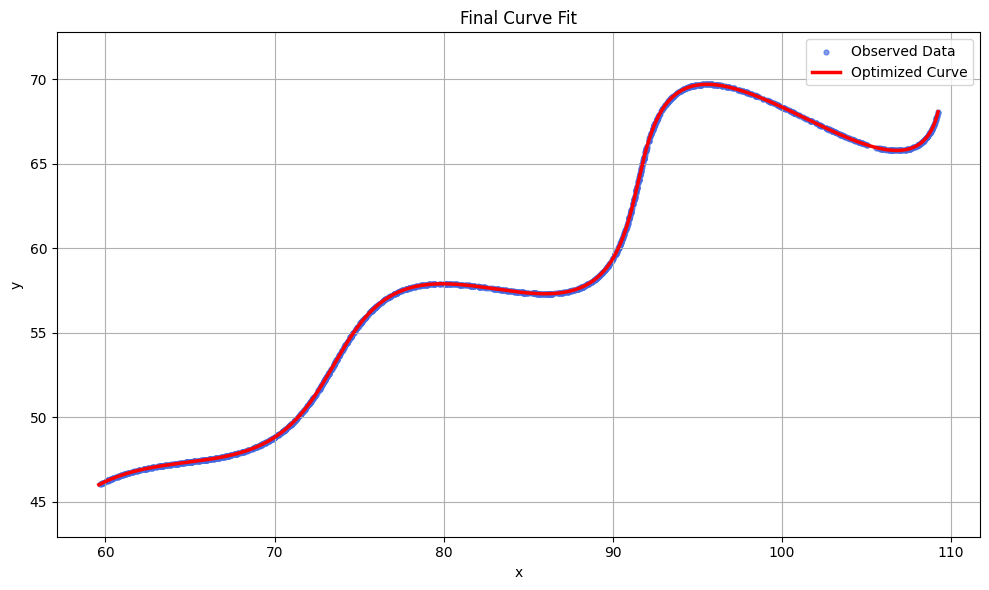

In [13]:
# STEP 10 : Final Model Validation
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# final predicted curve using optimized parameters

x_final, y_final = parametric_curve(
    t_dense,
    theta_opt,
    M_opt,
    X_opt
)

# Build KD-Tree

predicted_points = np.column_stack((x_final, y_final))
tree = cKDTree(predicted_points)

observed_points = df[["x", "y"]].values

distances, indices = tree.query(observed_points)

# Evaluation Metrics

l1_error = np.sum(np.abs(distances))
mean_error = np.mean(distances)
max_error = np.max(distances)
rmse = np.sqrt(np.mean(distances**2))

print("="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

print(f"L1 Error      : {l1_error:.6f}")
print(f"Mean Error    : {mean_error:.6f}")
print(f"Maximum Error : {max_error:.6f}")
print(f"RMSE          : {rmse:.6f}")

plt.figure(figsize=(10,6))

plt.scatter(
    df["x"],
    df["y"],
    s=12,
    color="royalblue",
    alpha=0.65,
    label="Observed Data"
)

plt.plot(
    x_final,
    y_final,
    color="red",
    linewidth=2.5,
    label="Optimized Curve"
)

plt.title("Final Curve Fit")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)
plt.axis("equal")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# STEP 11 : Final Results

import numpy as np

print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print("\nEstimated Parameters")
print("---------------------")

print(f"Theta (degrees) : {np.degrees(theta_opt):.6f}")
print(f"Theta (radians) : {theta_opt:.8f}")

print(f"M               : {M_opt:.8f}")

print(f"X               : {X_opt:.8f}")

print("\nFinal L1 Error")
print("---------------------")
print(f"{result.fun:.6f}")

print("\nParametric Equation")
print("---------------------")

equation = (
    f"(t*cos({theta_opt:.8f})"
    f"-exp({M_opt:.8f}*abs(t))*sin(0.3*t)*sin({theta_opt:.8f})"
    f"+{X_opt:.8f},"
    f"42+t*sin({theta_opt:.8f})"
    f"+exp({M_opt:.8f}*abs(t))*sin(0.3*t)*cos({theta_opt:.8f}))"
)

print(equation)

print("\nLaTeX Style")
print("---------------------")

latex_equation = (
    rf"\left("
    rf"t\cos({theta_opt:.8f})"
    rf"-e^{{{M_opt:.8f}|t|}}"
    rf"\sin(0.3t)"
    rf"\sin({theta_opt:.8f})"
    rf"+{X_opt:.8f},"
    rf"42+t\sin({theta_opt:.8f})"
    rf"+e^{{{M_opt:.8f}|t|}}"
    rf"\sin(0.3t)"
    rf"\cos({theta_opt:.8f})"
    rf"\right)"
)

print(latex_equation)

print("\nOptimization Summary")
print("---------------------")

print(f"Optimizer        : L-BFGS-B")
print(f"Optimization OK  : {result.success}")
print(f"Iterations        : {result.nit}")
print(f"Function Calls    : {result.nfev}")

print("=" * 70)

FINAL RESULTS

Estimated Parameters
---------------------
Theta (degrees) : 29.999947
Theta (radians) : 0.52359786
M               : 0.02999992
X               : 54.99994582

Final L1 Error
---------------------
4.849061

Parametric Equation
---------------------
(t*cos(0.52359786)-exp(0.02999992*abs(t))*sin(0.3*t)*sin(0.52359786)+54.99994582,42+t*sin(0.52359786)+exp(0.02999992*abs(t))*sin(0.3*t)*cos(0.52359786))

LaTeX Style
---------------------
\left(t\cos(0.52359786)-e^{0.02999992|t|}\sin(0.3t)\sin(0.52359786)+54.99994582,42+t\sin(0.52359786)+e^{0.02999992|t|}\sin(0.3t)\cos(0.52359786)\right)

Optimization Summary
---------------------
Optimizer        : L-BFGS-B
Optimization OK  : True
Iterations        : 22
Function Calls    : 188
